# 📊 Day 17 — Pandas Advanced (groupby, merge, pivot)
### 100 Days of Data Science | by Shoaib Aslam

---

## Table of Contents

1️⃣ What is Pandas Advanced  
2️⃣ Why These Functions Matter  
3️⃣ Loading the Dataset  
4️⃣ groupby — Split, Apply, Combine  
5️⃣ agg — Multiple Aggregations  
6️⃣ merge — Joining DataFrames  
7️⃣ concat — Stacking DataFrames  
8️⃣ pivot_table — Summarizing Data  
9️⃣ apply — Custom Functions on Columns  
🔟 When to Use What  

---
## 1️⃣ What is Pandas Advanced?

Pandas Advanced covers the most powerful data manipulation techniques used in real data science projects.

These include:
- **groupby** — group data and calculate statistics per group
- **agg** — apply multiple functions at once
- **merge** — join two DataFrames like SQL JOIN
- **concat** — stack DataFrames vertically or horizontally
- **pivot_table** — summarize data in a cross-tabular format
- **apply** — apply custom functions row by row or column by column

> **Key idea:** These six functions cover 90% of real data manipulation tasks in a data science job.

---
## 2️⃣ Why These Functions Matter?

| Function | What It Does | Real Use Case |
|----------|-------------|---------------|
| `groupby` | Group rows by category | Average salary per department |
| `agg` | Multiple stats at once | Min, max, mean salary per country |
| `merge` | Combine two DataFrames | Join sales with customer data |
| `concat` | Stack DataFrames | Combine Jan + Feb + Mar data |
| `pivot_table` | Cross-tab summary | Points by country and variety |
| `apply` | Custom logic per row/col | Create category from condition |

---
## 3️⃣ Loading the Dataset

In [1]:
# Importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
print("Libraries imported successfully!")

Libraries imported successfully!


In [4]:
# Load the Winemag dataset
df = pd.read_csv(r"C:\Users\aslam\Downloads\winemag-data-130k-v2.csv\winemag-data-130k-v2.csv", index_col=0)
df.head()

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [5]:
# Quick overview
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())

Shape: (129971, 13)
Columns: ['country', 'description', 'designation', 'points', 'price', 'province', 'region_1', 'region_2', 'taster_name', 'taster_twitter_handle', 'title', 'variety', 'winery']


In [6]:
# Clean missing values for key columns
df = df[['country', 'variety', 'points', 'price', 'winery', 'province']].dropna(subset=['country', 'variety', 'points', 'price'])
print("Cleaned shape:", df.shape)

Cleaned shape: (120915, 6)


---
## 4️⃣ groupby — Split, Apply, Combine

groupby splits the data into groups, applies a function, and combines the results.

In [7]:
# Average points per country
avg_points = df.groupby('country')['points'].mean().sort_values(ascending=False)
avg_points.head(10)

country
England       91.550725
India         90.222222
Austria       90.190782
Germany       89.836321
Canada        89.377953
Hungary       89.165517
China         89.000000
France        88.734867
Luxembourg    88.666667
Italy         88.618186
Name: points, dtype: float64

In [8]:
# Average price per country
avg_price = df.groupby('country')['price'].mean().sort_values(ascending=False)
avg_price.head(10)

country
Switzerland    85.285714
England        51.681159
Germany        42.257547
France         41.139120
Hungary        40.648276
Italy          39.663770
US             36.573464
Canada         35.712598
Australia      35.437663
Israel         31.768916
Name: price, dtype: float64

In [9]:
# Count of wines per country
wine_count = df.groupby('country')['points'].count().sort_values(ascending=False)
wine_count.head(10)

country
US           54265
France       17776
Italy        16914
Spain         6573
Portugal      4875
Chile         4415
Argentina     3756
Austria       2799
Australia     2294
Germany       2120
Name: points, dtype: int64

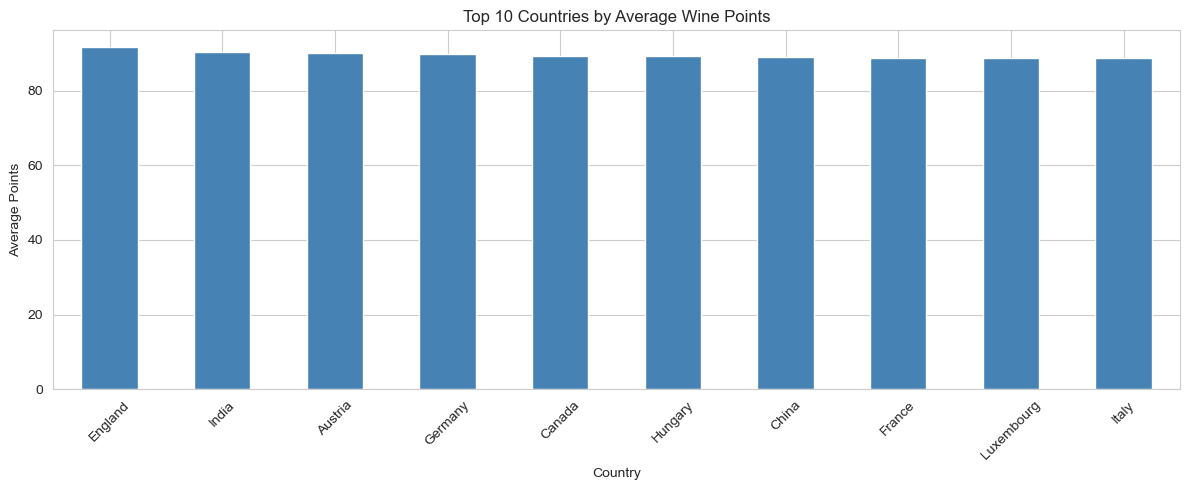

In [10]:
# Visualize top 10 countries by average points
plt.figure(figsize=(12, 5))
avg_points.head(10).plot(kind='bar', color='steelblue')
plt.title("Top 10 Countries by Average Wine Points")
plt.xlabel("Country")
plt.ylabel("Average Points")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [11]:
# groupby on multiple columns
# Average points per country AND variety
multi_group = df.groupby(['country', 'variety'])['points'].mean().reset_index()
multi_group.sort_values('points', ascending=False).head(10)

,country,variety,points
76,Australia,Cabernet-Shiraz,96.000000
1258,Spain,Tinta del Pais,95.000000
149,Austria,Gelber Traminer,95.000000
1030,Portugal,Terrantez,95.000000
1126,South Africa,Muscat,94.500000
976,Portugal,Bual,94.333333
1519,US,Syrah-Petit Verdot,94.000000
1428,US,Moscato Giallo,94.000000
94,Australia,Muscadelle,94.000000
145,Austria,Chardonnay Weissburgunder,94.000000


---
## 5️⃣ agg — Multiple Aggregations

agg applies multiple functions to a group at once — much faster than running groupby multiple times.

In [12]:
# Multiple stats per country in one shot
country_stats = df.groupby('country').agg(
    total_wines   = ('points', 'count'),
    avg_points    = ('points', 'mean'),
    avg_price     = ('price', 'mean'),
    min_price     = ('price', 'min'),
    max_price     = ('price', 'max')
).round(2).sort_values('avg_points', ascending=False)

country_stats.head(10)

,total_wines,avg_points,avg_price,min_price,max_price
country,,,,,
England,69,91.55,51.68,25.0,95.0
India,9,90.22,13.33,10.0,20.0
Austria,2799,90.19,30.76,7.0,1100.0
Germany,2120,89.84,42.26,5.0,775.0
Canada,254,89.38,35.71,12.0,120.0
Hungary,145,89.17,40.65,10.0,764.0
China,1,89.00,18.00,18.0,18.0
France,17776,88.73,41.14,5.0,3300.0
Luxembourg,6,88.67,23.33,16.0,30.0


In [13]:
# Top 5 most reviewed countries with full stats
country_stats.sort_values('total_wines', ascending=False).head(5)

,total_wines,avg_points,avg_price,min_price,max_price
country,,,,,
US,54265,88.57,36.57,4.0,2013.0
France,17776,88.73,41.14,5.0,3300.0
Italy,16914,88.62,39.66,5.0,900.0
Spain,6573,87.29,28.22,4.0,770.0
Portugal,4875,88.32,26.22,5.0,1000.0


---
## 6️⃣ merge — Joining DataFrames

merge combines two DataFrames based on a common column — just like SQL JOIN.

In [14]:
# Create two separate DataFrames to merge

# DataFrame 1 — Average points per country
df_points = df.groupby('country')['points'].mean().round(2).reset_index()
df_points.columns = ['country', 'avg_points']

# DataFrame 2 — Average price per country
df_price = df.groupby('country')['price'].mean().round(2).reset_index()
df_price.columns = ['country', 'avg_price']

print("Points DataFrame:")
df_points.head(3)

Points DataFrame:


,country,avg_points
0,Argentina,86.71
1,Armenia,87.50
2,Australia,88.60


In [15]:
# Inner merge — only countries present in BOTH DataFrames
merged_inner = pd.merge(df_points, df_price, on='country', how='inner')
print("Inner Merge shape:", merged_inner.shape)
merged_inner.head(5)

Inner Merge shape: (42, 3)


,country,avg_points,avg_price
0,Argentina,86.71,24.51
1,Armenia,87.50,14.50
2,Australia,88.60,35.44
3,Austria,90.19,30.76
4,Bosnia and Herzegovina,86.50,12.50


In [16]:
# Left merge — keep all rows from left DataFrame
merged_left = pd.merge(df_points, df_price, on='country', how='left')
print("Left Merge shape:", merged_left.shape)
merged_left.head(5)

Left Merge shape: (42, 3)


,country,avg_points,avg_price
0,Argentina,86.71,24.51
1,Armenia,87.50,14.50
2,Australia,88.60,35.44
3,Austria,90.19,30.76
4,Bosnia and Herzegovina,86.50,12.50


#### 💡 Tip — Types of Merge

| Merge Type | Keeps | Use When |
|------------|-------|----------|
| `inner` | Only matching rows in both | You want only complete records |
| `left` | All rows from left + matches from right | You want to keep all left data |
| `right` | All rows from right + matches from left | You want to keep all right data |
| `outer` | All rows from both | You want everything, fill missing with NaN |

---
## 7️⃣ concat — Stacking DataFrames

concat stacks DataFrames on top of each other (vertically) or side by side (horizontally).

In [17]:
# Split wines by top 3 countries
df_us    = df[df['country'] == 'US'].head(50)
df_italy = df[df['country'] == 'Italy'].head(50)
df_france = df[df['country'] == 'France'].head(50)

print("US shape:", df_us.shape)
print("Italy shape:", df_italy.shape)
print("France shape:", df_france.shape)

US shape: (50, 6)
Italy shape: (50, 6)
France shape: (50, 6)


In [18]:
# Vertical concat — stack all three together
df_combined = pd.concat([df_us, df_italy, df_france], ignore_index=True)
print("Combined shape:", df_combined.shape)
df_combined['country'].value_counts()

Combined shape: (150, 6)


country
US        50
Italy     50
France    50
Name: count, dtype: int64

In [19]:
# Horizontal concat — join side by side
df_h = pd.concat([df_points.head(5), df_price.head(5)], axis=1)
df_h

,country,avg_points,country,avg_price
0,Argentina,86.71,Argentina,24.51
1,Armenia,87.50,Armenia,14.50
2,Australia,88.60,Australia,35.44
3,Austria,90.19,Austria,30.76
4,Bosnia and Herzegovina,86.50,Bosnia and Herzegovina,12.50


---
## 8️⃣ pivot_table — Summarizing Data

pivot_table creates a cross-tabular summary — like an Excel pivot table.

In [20]:
# Filter top 5 countries and top 4 varieties
top_countries = df['country'].value_counts().head(5).index
top_varieties = df['variety'].value_counts().head(4).index

df_pivot = df[df['country'].isin(top_countries) & df['variety'].isin(top_varieties)]
print("Pivot dataset shape:", df_pivot.shape)

Pivot dataset shape: (35682, 6)


In [21]:
# Pivot table — average points by country and variety
pivot = pd.pivot_table(
    df_pivot,
    values='points',
    index='country',
    columns='variety',
    aggfunc='mean'
).round(2)

pivot

variety,Cabernet Sauvignon,Chardonnay,Pinot Noir,Red Blend
country,,,,
France,85.43,89.30,89.77,88.13
Italy,89.18,88.23,86.83,88.85
Portugal,88.40,87.65,88.20,88.57
Spain,87.21,84.82,87.00,88.14
US,89.03,88.45,89.61,87.85


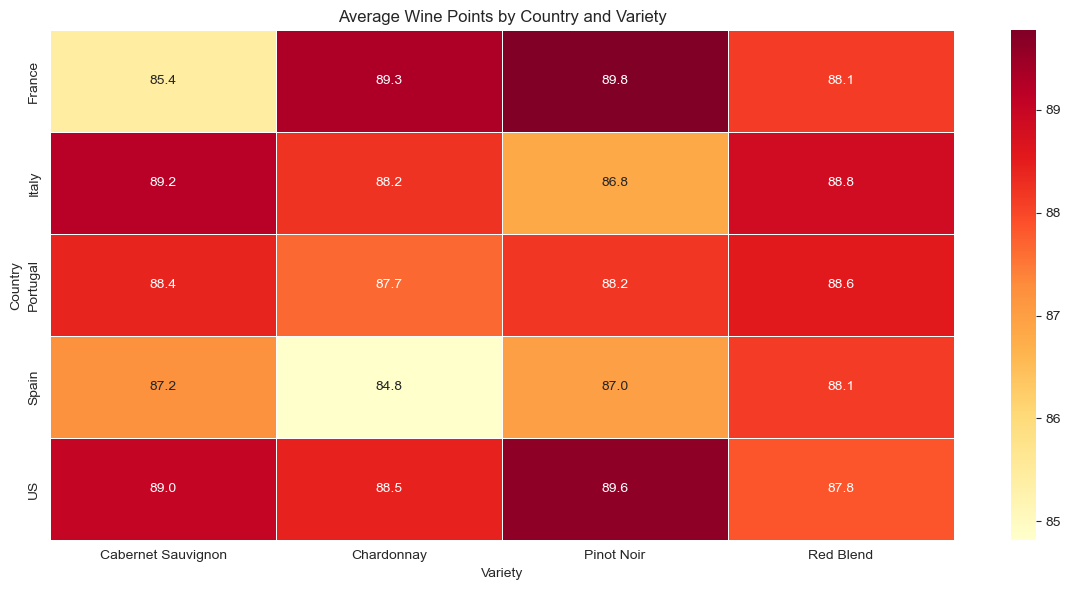

In [22]:
# Visualize pivot table as heatmap
plt.figure(figsize=(12, 6))
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5)
plt.title("Average Wine Points by Country and Variety")
plt.xlabel("Variety")
plt.ylabel("Country")
plt.tight_layout()
plt.show()

---
## 9️⃣ apply — Custom Functions on Columns

apply lets you run any custom function on each row or column.

In [23]:
# Apply a custom function — classify wine value
def classify_value(row):
    if row['points'] >= 90 and row['price'] < 20:
        return 'Hidden Gem'
    elif row['points'] >= 90 and row['price'] >= 20:
        return 'Premium'
    elif row['points'] < 90 and row['price'] < 20:
        return 'Budget'
    else:
        return 'Overpriced'

df['wine_category'] = df.apply(classify_value, axis=1)

print("Wine Category Distribution:")
df['wine_category'].value_counts()

Wine Category Distribution:


wine_category
Premium       41661
Overpriced    39871
Budget        35671
Hidden Gem     3712
Name: count, dtype: int64

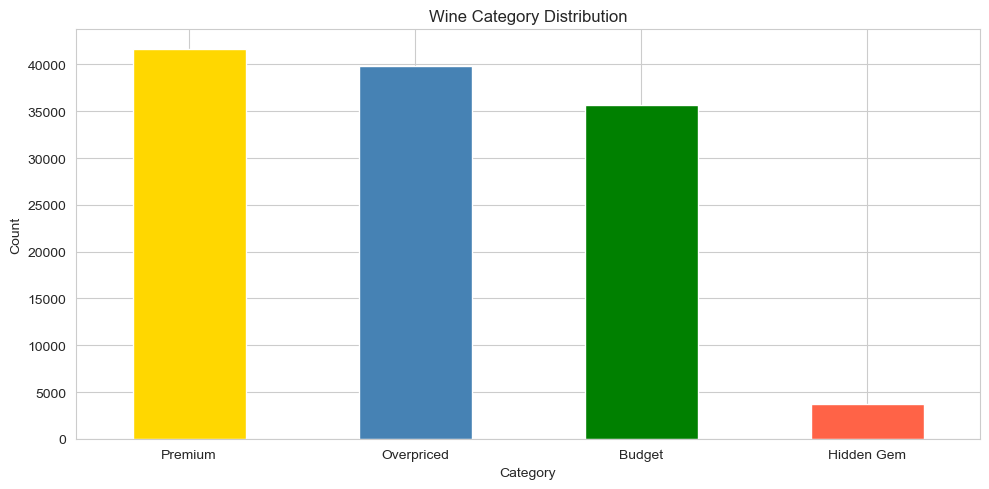

In [24]:
# Visualize wine categories
plt.figure(figsize=(10, 5))
df['wine_category'].value_counts().plot(kind='bar', color=['gold', 'steelblue', 'green', 'tomato'])
plt.title("Wine Category Distribution")
plt.xlabel("Category")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
# Apply lambda — quick one-liner function
df['price_category'] = df['price'].apply(lambda x: 'Expensive' if x > 50 else 'Affordable')

print("Price Category Distribution:")
df['price_category'].value_counts()

Price Category Distribution:


price_category
Affordable    101141
Expensive      19774
Name: count, dtype: int64

---
## 🔟 When to Use What

| Function | When to Use | Example |
|----------|-------------|--------|
| `groupby` | Summarize data by one category | Avg points per country |
| `agg` | Multiple stats in one step | Count, mean, min, max per group |
| `merge (inner)` | Keep only matching rows | Join sales + customers |
| `merge (left)` | Keep all left rows | Keep all wines, add country info |
| `concat` | Stack DataFrames | Combine monthly data files |
| `pivot_table` | Cross-tab summary | Points by country x variety |
| `apply` | Custom row-level logic | Classify wine as Hidden Gem |
| `lambda` | Quick one-line function | Label price as high or low |

---
## 🔑 Key Takeaways

→ `groupby` is the most used Pandas function in real data science projects  
→ Always use `agg` instead of running `groupby` multiple times — it is faster and cleaner  
→ `merge` works exactly like SQL JOIN — inner, left, right, outer  
→ `concat` is for stacking — use it when combining data from multiple sources  
→ `pivot_table` turns raw data into an instant summary report  
→ `apply` is powerful but slow on large datasets — use vectorized operations when possible  
→ `lambda` inside `apply` is perfect for quick one-liner transformations

---
## 📁 Connect & Follow the Journey

| Platform | Link |
|----------|------|
| 🐙 GitHub | https://github.com/imshoaibaslam/100-Days-of-Data-Science |
| 📊 Kaggle | https://www.kaggle.com/shoaib32922 |

---
*Day 17 of 100 — Keep Learning, Keep Building 🚀*